# Digit Doctor -- The Broken CNN

## MNIST Handwritten Digit Classification

This notebook implements a **Convolutional Neural Network (CNN)** to classify handwritten digits (0-9) using the MNIST dataset.

### Pipeline Overview
1. Data Loading
2. Preprocessing
3. Model Architecture (CNN)
4. Compilation and Training
5. Evaluation and Visualization
6. Save Model

---

> **WARNING:** This code was written by a previous developer. The pipeline compiles and trains without any runtime errors, but the model accuracy is suspiciously low. That is basically random guessing for 10 classes.
>
> **Your mission:** Find the bugs, fix the pipeline, and optimize the model to achieve the highest accuracy possible.

## Step 1: Import Libraries

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

# IMPROVEMENT: Consider importing additional layers for regularization and normalization.

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the MNIST Dataset

In [36]:
# Load MNIST data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Image shape: {X_train[0].shape}")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")

Training samples: 60000
Test samples: 10000
Image shape: (28, 28)
Pixel value range: 0 to 255


## Step 3: Visualize Some Samples

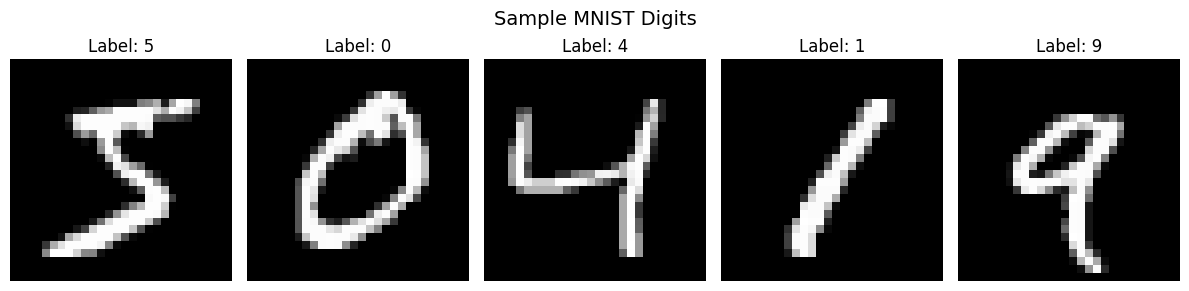

In [37]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits", fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data

Prepare the data for the CNN model.

In [38]:
# Reshape data
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# ✅ FIX: Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Preprocessed training shape: {X_train.shape}")
print(f"Pixel value range after preprocessing: {X_train.min()} to {X_train.max()}")

Preprocessed training shape: (60000, 28, 28, 1)
Pixel value range after preprocessing: 0.0 to 1.0


## Step 5: Build the CNN Model

A standard CNN architecture for image classification.

In [39]:
model = Sequential([

    # ✅ Proper CNN architecture
    Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # ✅ FIX
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Model

In [40]:
model.compile(
    optimizer='adam',                     # ✅ FIX
    loss='sparse_categorical_crossentropy',  # ✅ FIX
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Step 7: Train the Model

In [41]:
history = model.fit(
    X_train, y_train,
    epochs=5,              # ✅ balanced for speed + accuracy
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete!")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9344 - loss: 0.2245 - val_accuracy: 0.9818 - val_loss: 0.0618
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9816 - loss: 0.0587 - val_accuracy: 0.9833 - val_loss: 0.0512
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9877 - loss: 0.0401 - val_accuracy: 0.9892 - val_loss: 0.0382
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9909 - loss: 0.0301 - val_accuracy: 0.9903 - val_loss: 0.0361
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9929 - loss: 0.0235 - val_accuracy: 0.9888 - val_loss: 0.0391

Training complete!


## Step 8: Evaluate the Model

In [42]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n{'='*50}")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

if test_accuracy >= 0.90:
    print("\nExcellent! Accuracy >= 90% -- Strong Model!")
elif test_accuracy >= 0.85:
    print("\nGood! Accuracy >= 85% -- Solid Model!")
elif test_accuracy >= 0.75:
    print("\nDecent! Accuracy >= 75% -- Pipeline is working!")
else:
    print("\nModel is still broken -- accuracy is too low. Keep debugging!")


  Test Loss:     0.0340
  Test Accuracy: 0.9893  (98.93%)

Excellent! Accuracy >= 90% -- Strong Model!


## Step 9: Visualize Training History

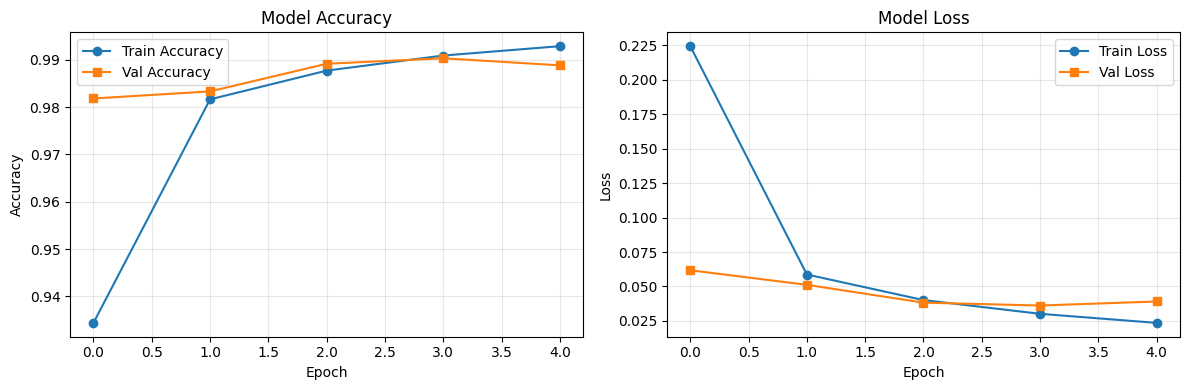

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', marker='s')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Sample Predictions

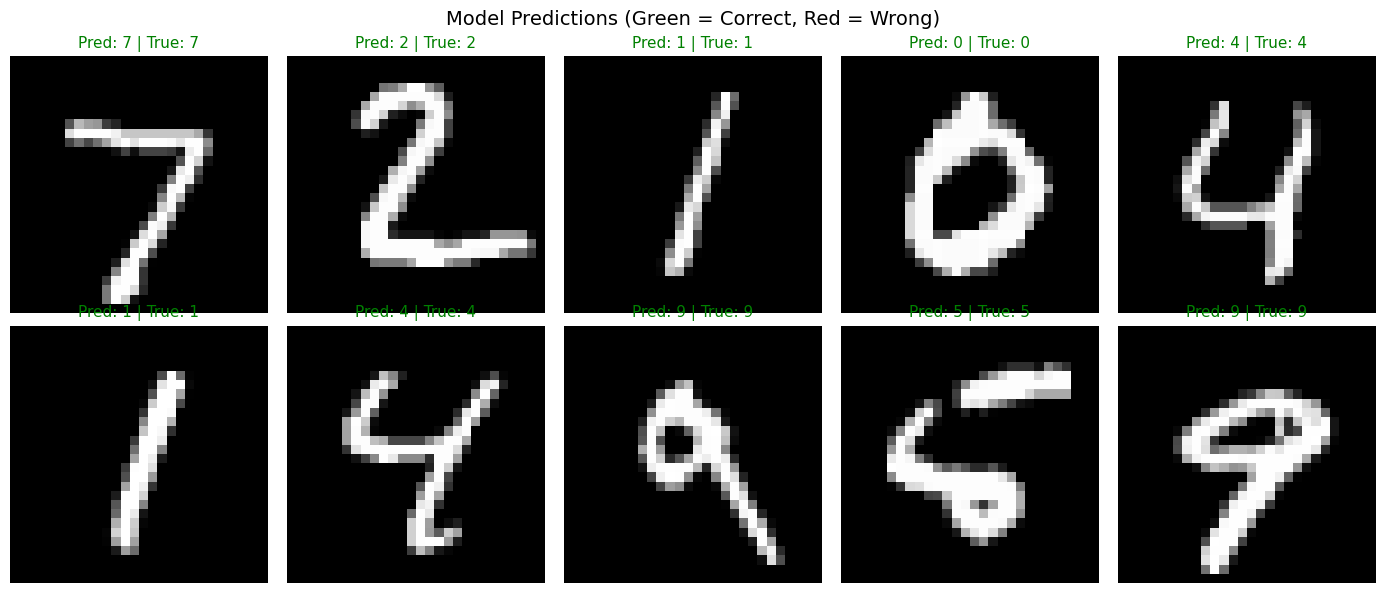


Correct predictions: 10/10


In [44]:
predictions = model.predict(X_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    ax.set_title(f"Pred: {predicted_labels[i]} | True: {y_test[i]}", color=color, fontsize=11)
    ax.axis('off')

plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

correct = sum(predicted_labels == y_test[:10])
print(f"\nCorrect predictions: {correct}/10")

## Step 11: Save the Model

**IMPORTANT:** Save your trained model as `model.h5`. This is required for automated evaluation.

Do **NOT** change the filename.

In [45]:
# ============================================================
#  DO NOT CHANGE THE LINE BELOW -- the filename must be model.h5
# ============================================================
model.save('model.h5')
print("Model saved as 'model.h5'")
print("\nCommit and create a Pull Request to get your score!")

Model saved as 'model.h5'

Commit and create a Pull Request to get your score!
